<a href="https://colab.research.google.com/github/mib-a/ML-DL/blob/main/3%20Deep%20Learning/Module%2017%20Loss%20Fn%20%26%20VGD/17_Vanishing_Gradient_Descent.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Vanishing Gradient Descent
Gradient Descent so small, so multiplying very small numbers multiple times makes very very small negligible number, so the weight updation can't be done properly. hence, the model can't refine itself and become better. That's what is called Vanishing Gradient Descent.

In [172]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import numpy as np
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split


In [173]:
# reproducibility
torch.manual_seed(42)

## Example of Vanishing GD
- Lots of Neural Networks
- Sigmoid Activation Function

### Dataset

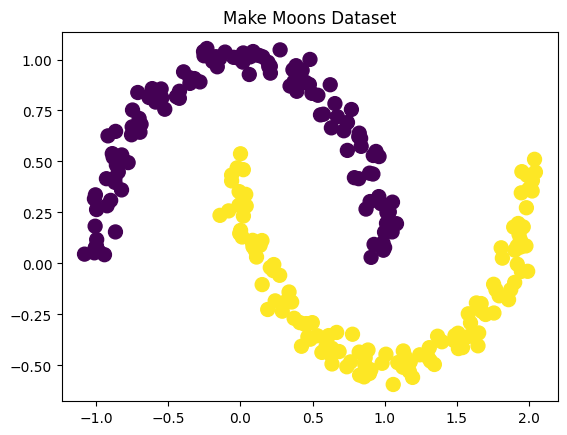

In [174]:
X, y = make_moons(n_samples=250, noise=0.05, random_state=42)

plt.scatter(X[:,0], X[:,1], c=y, s=100)
plt.title("Make Moons Dataset")
plt.show()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

### Converting to Tensor X/y test, train,

In [175]:
# convert to tensors
X_train = torch.tensor(X_train, dtype=torch.float32)
X_test = torch.tensor(X_test, dtype=torch.float32)

y_train = torch.tensor(y_train.reshape(-1,1), dtype=torch.float32)
y_test = torch.tensor(y_test.reshape(-1,1), dtype=torch.float32)


### Making the SigmoidNet Class

## Here change the code twice to inspect the impact of methods to solve VGD
1. Reduce model Complexity (Doesnt work always, cause simplified models can't work with complex datasets)
2. change the Activation Function: Simgoid to ReLU. Why? ReLU gives you exact number or zero, while Sigmoid only gives you number between 0 to 1 which is smaller than ReLU, so VGD finds more opportunit there.

## Base Model Structure

In [176]:
# # Base Code
# class SigmoidNet(nn.Module):

#     def __init__(self):
#         super().__init__()

#         self.net = nn.Sequential(
#             nn.Linear(2,10), nn.Sigmoid(),
#             nn.Linear(10,10), nn.Sigmoid(),
#             nn.Linear(10,10), nn.Sigmoid(),
#             nn.Linear(10,10), nn.Sigmoid(),
#             nn.Linear(10,10), nn.Sigmoid(),
#             nn.Linear(10,10), nn.Sigmoid(),
#             nn.Linear(10,10), nn.Sigmoid(),
#             nn.Linear(10,10), nn.Sigmoid(),
#             nn.Linear(10,10), nn.Sigmoid(),
#             nn.Linear(10,10), nn.Sigmoid(),
#             nn.Linear(10,10), nn.Sigmoid(),
#             nn.Linear(10,10), nn.Sigmoid(),
#             nn.Linear(10,10), nn.Sigmoid(),
#             nn.Linear(10,10), nn.Sigmoid(),
#             nn.Linear(10,10), nn.Sigmoid(),
#             nn.Linear(10,1), nn.Sigmoid(),
#         )

#     def forward(self,x):
#         return self.net(x)

# model = SigmoidNet()


## Solve VGD 01: Reduce Complexity

In [177]:
# # Reducing Model Complexity (Less Nueral Network)
# class SigmoidNet(nn.Module):

#     def __init__(self):
#         super().__init__()

#         self.net = nn.Sequential(
#             nn.Linear(2,10), nn.Sigmoid(),
#             nn.Linear(10,10), nn.Sigmoid(),
#             nn.Linear(10,10), nn.Sigmoid(),
#             # nn.Linear(10,10), nn.Sigmoid(),
#             # nn.Linear(10,10), nn.Sigmoid(),
#             # nn.Linear(10,10), nn.Sigmoid(),
#             # nn.Linear(10,10), nn.Sigmoid(),
#             # nn.Linear(10,10), nn.Sigmoid(),
#             # nn.Linear(10,10), nn.Sigmoid(),
#             # nn.Linear(10,10), nn.Sigmoid(),
#             # nn.Linear(10,10), nn.Sigmoid(),
#             # nn.Linear(10,10), nn.Sigmoid(),
#             nn.Linear(10,10), nn.Sigmoid(),
#             nn.Linear(10,10), nn.Sigmoid(),
#             nn.Linear(10,10), nn.Sigmoid(),
#             nn.Linear(10,1), nn.Sigmoid(),
#         )

#     def forward(self,x):
#         return self.net(x)

# model = SigmoidNet()

## Solve VGD 02: ReLU ACT

In [178]:
# # Changing the ACT
# class SigmoidNet(nn.Module):

#     def __init__(self):
#         super().__init__()

#         self.net = nn.Sequential(
#             nn.Linear(2,10), nn.ReLU(),
#             nn.Linear(10,10), nn.ReLU(),
#             nn.Linear(10,10), nn.ReLU(),
#             nn.Linear(10,10), nn.ReLU(),
#             nn.Linear(10,10), nn.ReLU(),
#             nn.Linear(10,10), nn.ReLU(),
#             nn.Linear(10,10), nn.ReLU(),
#             nn.Linear(10,10), nn.ReLU(),
#             nn.Linear(10,10), nn.ReLU(),
#             nn.Linear(10,10), nn.ReLU(),
#             nn.Linear(10,10), nn.ReLU(),
#             nn.Linear(10,1), nn.ReLU(),
#         )

#     def forward(self,x):
#         return self.net(x)


# model = SigmoidNet()

I dont know why it's not working just, giving a straight line. lol!

## Experiment: Applying Both

In [179]:
# doing both together
class SigmoidNet(nn.Module):

    def __init__(self):
        super().__init__()

        self.net = nn.Sequential(
            nn.Linear(2,10), nn.ReLU(),
            nn.Linear(10,10), nn.ReLU(),
            nn.Linear(10,10), nn.ReLU(),
            nn.Linear(10,10), nn.ReLU(),
            # nn.Linear(10,10), nn.ReLU(),
            # nn.Linear(10,10), nn.ReLU(),
            # nn.Linear(10,10), nn.ReLU(),
            # nn.Linear(10,10), nn.ReLU(),
            # nn.Linear(10,10), nn.ReLU(),
            # nn.Linear(10,10), nn.ReLU(),
            # nn.Linear(10,10), nn.ReLU(),
            # nn.Linear(10,10), nn.ReLU(),
            # nn.Linear(10,10), nn.ReLU(),
            # nn.Linear(10,10), nn.ReLU(),
            nn.Linear(10,10), nn.ReLU(),
            nn.Linear(10,1), nn.ReLU(),
        )

    def forward(self,x):
        return self.net(x)


model = SigmoidNet()

### Loss Optimization

In [180]:
criterion = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)




### Initialize Weight

In [181]:
old_weights = model.net[0].weight.data.clone().numpy()

### Capturing the changes of weights (to plot weight movement)

In [182]:
# for plotting weight movement
initial_weights = model.net[0].weight.data.clone()
weight_changes = []

### Training the dataset with that model & track weight movement

In [183]:
epochs = 100

for epoch in range(epochs):

    optimizer.zero_grad()

    y_pred = model(X_train)

    loss = criterion(y_pred, y_train)

    loss.backward()

    optimizer.step()

    # track weight movement
    current_weights = model.net[0].weight.data.clone()

    change = torch.mean(torch.abs(current_weights - initial_weights)).item()

    weight_changes.append(change)

    if epoch % 10 == 0:
        print(f"Epoch {epoch} Loss: {loss.item():.4f}")

Epoch 0 Loss: 1.0048
Epoch 10 Loss: 0.9060
Epoch 20 Loss: 0.8400
Epoch 30 Loss: 0.7970
Epoch 40 Loss: 0.7634
Epoch 50 Loss: 0.7371
Epoch 60 Loss: 0.7159
Epoch 70 Loss: 0.6983
Epoch 80 Loss: 0.6819
Epoch 90 Loss: 0.6644


In [184]:
# Save new Weights

new_weights = model.net[0].weight.data.clone().numpy()


### Computing Gradient

In [185]:
learning_rate = 0.001

gradient = (old_weights - new_weights) / learning_rate

percent_change = np.abs(100 * (old_weights - new_weights) / old_weights)

print("\nGradient:\n", gradient)

print("\nPercent Change:\n", percent_change)


Gradient:
 [[  22.393822 -127.97844 ]
 [  74.3477   -100.760155]
 [   0.          0.      ]
 [-126.70661   131.0344  ]
 [ -80.31183    98.51211 ]
 [  38.52111   -59.281853]
 [ -73.82428   109.11532 ]
 [  28.505533  -44.639862]
 [ -21.884262  104.63587 ]
 [   0.          0.      ]]

Percent Change:
 [[  4.142322   21.805677 ]
 [ 44.880875   15.512153 ]
 [  0.          0.       ]
 [ 36.805664   31.553907 ]
 [ 12.884011   18.990162 ]
 [  6.2675242  44.79457  ]
 [ 14.131301  113.94205  ]
 [  8.360413   44.712692 ]
 [  4.0147347 100.11405  ]
 [  0.          0.       ]]


### Plotting the Change of Weight

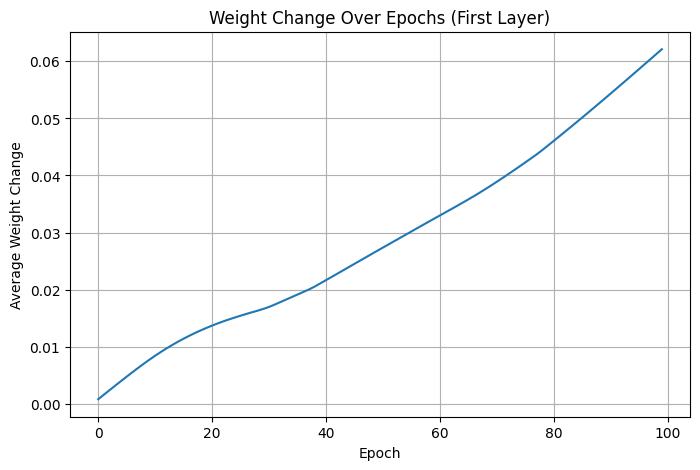

In [186]:
# =========================
# 8. Plot Weight Change
# =========================

plt.figure(figsize=(8,5))
plt.plot(weight_changes)

plt.xlabel("Epoch")
plt.ylabel("Average Weight Change")
plt.title("Weight Change Over Epochs (First Layer)")
plt.grid(True)

plt.show()

problem & update:
The ReLU is not working, should've worked.